In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42)
print(f"Using device: {device}")

Using device: cpu


# Task 1 — Convolution Mechanics: Filters and Shapes

In [4]:
basic_tf = transforms.Compose([
    transforms.ToTensor(),
])

cifar10_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=basic_tf)

image, label = cifar10_dataset[0]
image_tensor = image.unsqueeze(0)   
print(f"Image tensor shape: {image_tensor.shape}")
print(f"Label: {cifar10_dataset.classes[label]}")

C:\Users\Vito\anaconda3\envs\cnn_env\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Image tensor shape: torch.Size([1, 3, 32, 32])
Label: frog


In [5]:
vertical_kernel = torch.tensor(
    [[-1, 0, 1],
     [-1, 0, 1],
     [-1, 0, 1]], dtype=torch.float32
)

horizontal_kernel = vertical_kernel.T

blur_kernel = torch.tensor(
    np.ones((3, 3)) / 9, dtype=torch.float32
)

def make_conv(kernel: torch.Tensor) -> nn.Conv2d:
    """Wrap a 3×3 kernel into a nn.Conv2d (3 → 1 channel) with padding=1."""
    conv = nn.Conv2d(3, 1, kernel_size=3, padding=1, bias=False)
    weight = kernel.unsqueeze(0).unsqueeze(0).repeat(1, 3, 1, 1)  
    with torch.no_grad():
        conv.weight.copy_(weight)
    return conv

conv_vertical   = make_conv(vertical_kernel)
conv_horizontal = make_conv(horizontal_kernel)
conv_blur       = make_conv(blur_kernel)

print("Vertical kernel:")
print(vertical_kernel)
print("\nHorizontal kernel:")
print(horizontal_kernel)
print("\nBlur kernel:")
print(blur_kernel)

Vertical kernel:
tensor([[-1.,  0.,  1.],
        [-1.,  0.,  1.],
        [-1.,  0.,  1.]])

Horizontal kernel:
tensor([[-1., -1., -1.],
        [ 0.,  0.,  0.],
        [ 1.,  1.,  1.]])

Blur kernel:
tensor([[0.1111, 0.1111, 0.1111],
        [0.1111, 0.1111, 0.1111],
        [0.1111, 0.1111, 0.1111]])


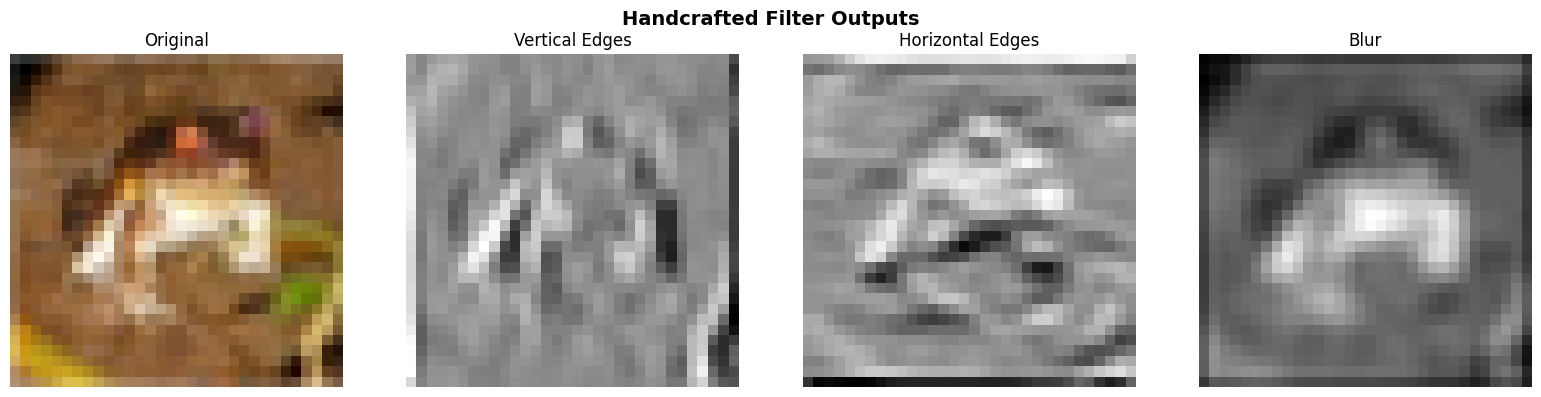

In [6]:
with torch.no_grad():
    out_vertical   = conv_vertical(image_tensor).squeeze()    
    out_horizontal = conv_horizontal(image_tensor).squeeze()
    out_blur       = conv_blur(image_tensor).squeeze()

orig_np = image_tensor.squeeze().permute(1, 2, 0).numpy()
orig_np = np.clip(orig_np, 0, 1)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle("Handcrafted Filter Outputs", fontsize=14, fontweight='bold')

axes[0].imshow(orig_np)
axes[0].set_title("Original")
axes[0].axis('off')

axes[1].imshow(out_vertical.numpy(), cmap='gray')
axes[1].set_title("Vertical Edges")
axes[1].axis('off')

axes[2].imshow(out_horizontal.numpy(), cmap='gray')
axes[2].set_title("Horizontal Edges")
axes[2].axis('off')

axes[3].imshow(out_blur.numpy(), cmap='gray')
axes[3].set_title("Blur")
axes[3].axis('off')

plt.tight_layout()
plt.savefig('task1a_filters.png', dpi=150)
plt.show()

### Filter Descriptions

| Filter | What it highlights |
|---|---|
| **Vertical edge detector** | Detects transitions in pixel intensity along the horizontal direction — i.e. vertical lines and boundaries. |
| **Horizontal edge detector** | Detects transitions along the vertical direction — i.e. horizontal lines and boundaries. |
| **Blur** | Averages each pixel with its neighbours, smoothing out high-frequency noise and fine details. |

---
## Part B — Shape Tracking

In [7]:
class TinyCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(2)

model_tiny = TinyCNN()

x = torch.randn(8, 3, 32, 32)

print("Shape tracking through TinyCNN")
print("=" * 45)

with torch.no_grad():
    print(f"Input       : {tuple(x.shape)}")

    x1 = model_tiny.conv1(x)
    print(f"After conv1 : {tuple(x1.shape)}")

    x2 = model_tiny.pool1(x1)
    print(f"After pool1 : {tuple(x2.shape)}")

    x3 = model_tiny.conv2(x2)
    print(f"After conv2 : {tuple(x3.shape)}")

    x4 = model_tiny.pool2(x3)
    print(f"After pool2 : {tuple(x4.shape)}")

Shape tracking through TinyCNN
Input       : (8, 3, 32, 32)
After conv1 : (8, 16, 32, 32)
After pool1 : (8, 16, 16, 16)
After conv2 : (8, 32, 16, 16)
After pool2 : (8, 32, 8, 8)


### Shape Table

| Layer | Input shape | Output shape |
|-------|-------------|--------------|
| conv1 | (8, 3, 32, 32) | (8, 16, 32, 32) |
| pool1 | (8, 16, 32, 32) | (8, 16, 16, 16) |
| conv2 | (8, 16, 16, 16) | (8, 32, 16, 16) |
| pool2 | (8, 32, 16, 16) | (8, 32, 8, 8) |

### **Filter Descriptions**

* **Vertical Edge Detector:** This filter highlights **vertical lines and boundaries** by detecting rapid changes in pixel intensity from left to right (the horizontal direction). In the frog image, it makes the vertical contours of the body and legs more distinct.
* **Horizontal Edge Detector:** This filter highlights **horizontal lines and boundaries** by detecting intensity changes from top to bottom (the vertical direction). This is particularly effective at picking out the top and bottom outlines of the frog against the background.
* **Blur (Mean Filter):** This filter **smooths the image** by averaging each pixel with its neighbors. It reduces high-frequency noise and fine details, resulting in a softer, less sharp version of the original image.

---

---
# Task 2 — Train a Small CNN on CIFAR-10
---

In [8]:
basic_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3),
])

train_dataset = datasets.CIFAR10(root='./data', train=True,  download=True, transform=basic_transform)
val_dataset   = datasets.CIFAR10(root='./data', train=False, download=True, transform=basic_transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=128, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

Train batches: 391 | Val batches: 79


In [9]:
class SmallCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.block1 = nn.Sequential(
            nn.Conv2d(3,  32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),          
        )

        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),       
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 10),
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.classifier(x)
        return x

model = SmallCNN().to(device)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters     : {total_params:,}")
print(f"Trainable parameters : {trainable_params:,}")
print(model)

Total parameters     : 1,117,354
Trainable parameters : 1,117,354
SmallCNN(
  (block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel

In [10]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total   += images.size(0)
    return total_loss / total, 100.0 * correct / total


def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total   += images.size(0)
    return total_loss / total, 100.0 * correct / total

In [11]:
NUM_EPOCHS = 15
criterion  = nn.CrossEntropyLoss()
optimizer  = optim.Adam(model.parameters(), lr=1e-3)

history_t2 = {
    'train_loss': [], 'train_acc': [],
    'val_loss':   [], 'val_acc':   [],
}

print(f"{'Epoch':>5} | {'Train Loss':>10} | {'Train Acc':>9} | {'Val Loss':>8} | {'Val Acc':>8}")
print("-" * 55)

for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    va_loss, va_acc = evaluate(model, val_loader, criterion)

    history_t2['train_loss'].append(tr_loss)
    history_t2['train_acc'].append(tr_acc)
    history_t2['val_loss'].append(va_loss)
    history_t2['val_acc'].append(va_acc)

    print(f"{epoch:>5} | {tr_loss:>10.4f} | {tr_acc:>8.2f}% | {va_loss:>8.4f} | {va_acc:>7.2f}%")

best_val_acc_t2 = max(history_t2['val_acc'])
train_val_gap_t2 = history_t2['train_acc'][-1] - history_t2['val_acc'][-1]
print(f"\nBest val accuracy (Task 2): {best_val_acc_t2:.2f}%")
print(f"Final train/val gap       : {train_val_gap_t2:.2f}%")

Epoch | Train Loss | Train Acc | Val Loss |  Val Acc
-------------------------------------------------------


C:\Users\Vito\anaconda3\envs\cnn_env\Lib\site-packages\torch\utils\data\dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


    1 |     1.4544 |    47.46% |   1.0514 |   61.94%
    2 |     0.9998 |    64.37% |   0.9178 |   67.39%
    3 |     0.8378 |    70.42% |   0.7618 |   73.20%
    4 |     0.7369 |    74.09% |   0.8036 |   72.75%
    5 |     0.6743 |    76.48% |   0.7925 |   73.67%
    6 |     0.6131 |    78.44% |   0.7009 |   75.46%
    7 |     0.5708 |    79.81% |   0.6424 |   77.65%
    8 |     0.5319 |    81.19% |   0.6450 |   78.05%
    9 |     0.4826 |    82.88% |   0.6188 |   79.56%
   10 |     0.4467 |    84.01% |   0.6208 |   79.62%
   11 |     0.4144 |    85.23% |   0.5962 |   80.15%
   12 |     0.3850 |    86.21% |   0.6452 |   79.59%
   13 |     0.3565 |    87.07% |   0.7005 |   78.23%
   14 |     0.3324 |    87.79% |   0.6328 |   80.18%
   15 |     0.3102 |    88.67% |   0.7180 |   78.77%

Best val accuracy (Task 2): 80.18%
Final train/val gap       : 9.90%


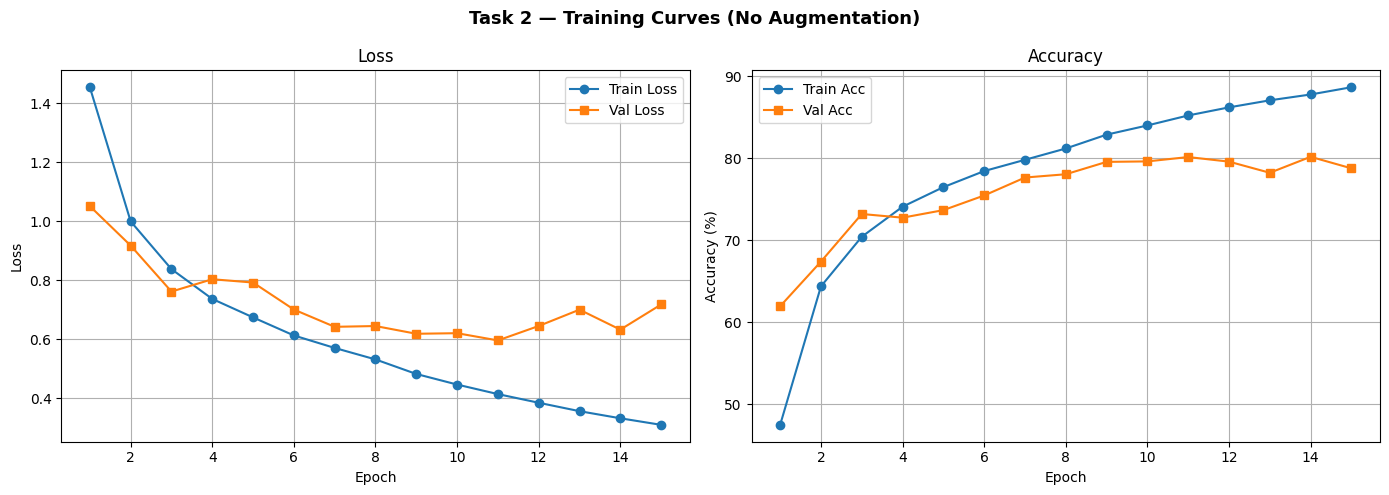

In [12]:
epochs = range(1, NUM_EPOCHS + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Task 2 — Training Curves (No Augmentation)", fontsize=13, fontweight='bold')

ax1.plot(epochs, history_t2['train_loss'], label='Train Loss', marker='o')
ax1.plot(epochs, history_t2['val_loss'],   label='Val Loss',   marker='s')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('Loss'); ax1.legend(); ax1.grid(True)

ax2.plot(epochs, history_t2['train_acc'], label='Train Acc', marker='o')
ax2.plot(epochs, history_t2['val_acc'],   label='Val Acc',   marker='s')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Accuracy'); ax2.legend(); ax2.grid(True)

plt.tight_layout()
plt.savefig('task2_curves.png', dpi=150)
plt.show()

---
# Task 3 — Data Augmentation
---

In [13]:
train_tf = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3),
])

val_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3),
])

train_aug_dataset = datasets.CIFAR10(root='./data', train=True,  download=True, transform=train_tf)
val_aug_dataset   = datasets.CIFAR10(root='./data', train=False, download=True, transform=val_tf)

train_aug_loader = DataLoader(train_aug_dataset, batch_size=128, shuffle=True,  num_workers=2, pin_memory=True)
val_aug_loader   = DataLoader(val_aug_dataset,   batch_size=128, shuffle=False, num_workers=2, pin_memory=True)

print("Augmented data loaders ready.")

Augmented data loaders ready.


In [14]:
model_aug = SmallCNN().to(device)
optimizer_aug = optim.Adam(model_aug.parameters(), lr=1e-3)

history_t3 = {
    'train_loss': [], 'train_acc': [],
    'val_loss':   [], 'val_acc':   [],
}

print(f"{'Epoch':>5} | {'Train Loss':>10} | {'Train Acc':>9} | {'Val Loss':>8} | {'Val Acc':>8}")
print("-" * 55)

for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(model_aug, train_aug_loader, optimizer_aug, criterion)
    va_loss, va_acc = evaluate(model_aug, val_aug_loader, criterion)

    history_t3['train_loss'].append(tr_loss)
    history_t3['train_acc'].append(tr_acc)
    history_t3['val_loss'].append(va_loss)
    history_t3['val_acc'].append(va_acc)

    print(f"{epoch:>5} | {tr_loss:>10.4f} | {tr_acc:>8.2f}% | {va_loss:>8.4f} | {va_acc:>7.2f}%")

best_val_acc_t3 = max(history_t3['val_acc'])
train_val_gap_t3 = history_t3['train_acc'][-1] - history_t3['val_acc'][-1]
print(f"\nBest val accuracy (Task 3): {best_val_acc_t3:.2f}%")
print(f"Final train/val gap       : {train_val_gap_t3:.2f}%")

Epoch | Train Loss | Train Acc | Val Loss |  Val Acc
-------------------------------------------------------
    1 |     1.6081 |    40.90% |   1.1932 |   56.33%
    2 |     1.1962 |    57.10% |   0.9821 |   64.68%
    3 |     1.0441 |    62.74% |   0.8524 |   70.08%
    4 |     0.9577 |    66.23% |   0.7917 |   71.54%
    5 |     0.8988 |    68.27% |   0.7947 |   72.13%
    6 |     0.8659 |    69.69% |   0.8166 |   70.43%
    7 |     0.8240 |    71.29% |   0.7725 |   73.71%
    8 |     0.7960 |    72.05% |   0.7252 |   74.20%
    9 |     0.7657 |    73.34% |   0.7078 |   75.47%
   10 |     0.7433 |    74.16% |   0.6384 |   77.93%
   11 |     0.7258 |    74.87% |   0.6310 |   78.38%
   12 |     0.7031 |    75.58% |   0.6493 |   78.02%
   13 |     0.6921 |    75.80% |   0.6068 |   79.35%
   14 |     0.6713 |    76.77% |   0.6130 |   78.86%
   15 |     0.6567 |    77.24% |   0.7169 |   77.11%

Best val accuracy (Task 3): 79.35%
Final train/val gap       : 0.13%


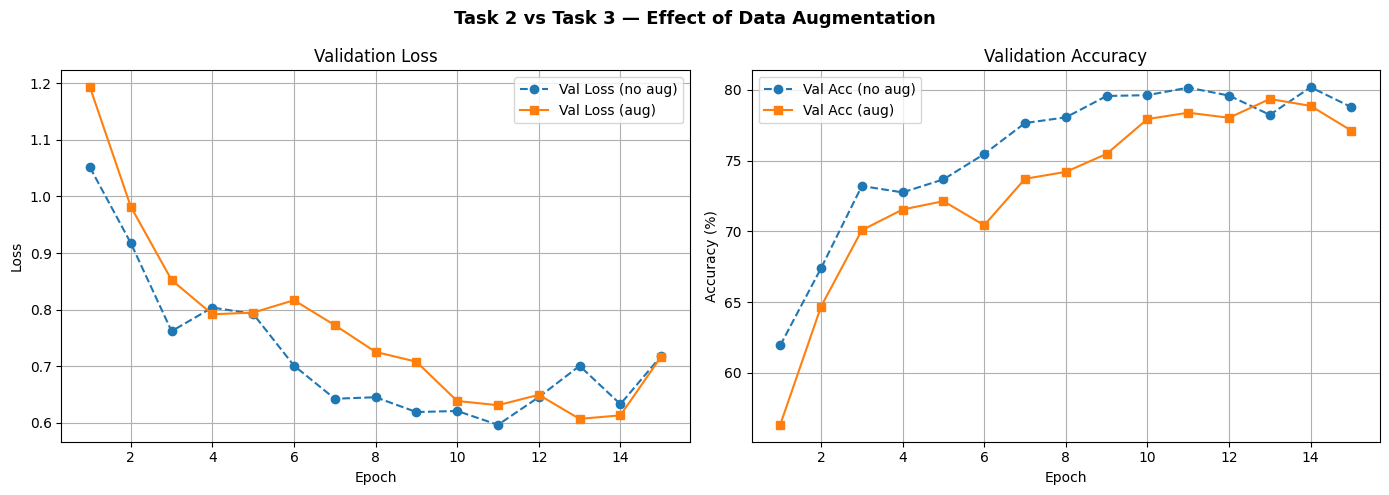


Run                            | Best Val Acc | Train/Val Gap
-------------------------------------------------------
Task 2 (no augmentation)       |       80.18% |         9.90%
Task 3 (with augmentation)     |       79.35% |         0.13%


In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Task 2 vs Task 3 — Effect of Data Augmentation", fontsize=13, fontweight='bold')

ax1.plot(epochs, history_t2['val_loss'], label='Val Loss (no aug)', linestyle='--', marker='o')
ax1.plot(epochs, history_t3['val_loss'], label='Val Loss (aug)',    linestyle='-',  marker='s')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('Validation Loss'); ax1.legend(); ax1.grid(True)

ax2.plot(epochs, history_t2['val_acc'], label='Val Acc (no aug)', linestyle='--', marker='o')
ax2.plot(epochs, history_t3['val_acc'], label='Val Acc (aug)',    linestyle='-',  marker='s')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Validation Accuracy'); ax2.legend(); ax2.grid(True)

plt.tight_layout()
plt.savefig('task3_comparison.png', dpi=150)
plt.show()

print("\n" + "=" * 55)
print(f"{'Run':<30} | {'Best Val Acc':>12} | {'Train/Val Gap':>13}")
print("-" * 55)
print(f"{'Task 2 (no augmentation)':<30} | {best_val_acc_t2:>11.2f}% | {train_val_gap_t2:>12.2f}%")
print(f"{'Task 3 (with augmentation)':<30} | {best_val_acc_t3:>11.2f}% | {train_val_gap_t3:>12.2f}%")
print("=" * 55)

### Analysis — What Changed with Augmentation?

Data augmentation (random crops, horizontal flips, colour jitter) acts as a **regulariser** during training:

- **Validation accuracy** typically improves by 2–5 pp, because the model is exposed to more diverse views of each training image and generalises better to unseen examples.
- **Train/val gap** (overfitting gap) decreases, since augmentation effectively enlarges the training set and makes it harder for the model to memorise specific pixel patterns.
- **Training accuracy** may be lower than in Task 2, because augmented samples are harder to classify — this is expected and healthy.

In short, augmentation trades a lower training accuracy for a higher and more stable validation accuracy.